# Method 3: Unsupervised Greedy Pretraining 

### Workflow
- Learn representations layer-by-layer using autoencoders (7 → 64 → 32 → 7), then switch to supervised fine-tuning (7 → 64 → 32 → 1)

### Steps
1. Train autoencoder: `7 → 64 → 7`  
2. Freeze first layer (`7 → 64`) → train deeper autoencoder: `7 → 64 → 32 → 7`  
3. Freeze both hidden layers (`7 → 64 → 32`) → train classifier: `7 → 64 → 32 → 1`  
4. Save final-stage checkpoints  
5. Evaluate checkpoints on validation set  
6. Select best checkpoint → test performance  


In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import clear_output
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from mcp_tool import MCPTool

sns.set_theme(style="darkgrid")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cpu


In [2]:
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
if torch.cuda.is_available():
    torch.cuda.manual_seed(0)
    torch.cuda.manual_seed_all(0)
if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [3]:
DATA_DIR = Path("./classification_data")
UNSUP_ROOT = Path("./greedy_unsupervised_outputs")
UNSUP_ROOT.mkdir(parents=True, exist_ok=True)
UNSUP_CKPT_DIR = Path("./greedy_unsupervised_ckpts")
UNSUP_CKPT_DIR.mkdir(parents=True, exist_ok=True)

X_train = np.load(DATA_DIR / "X_train.npy").astype(np.float32)
X_val = np.load(DATA_DIR / "X_val.npy").astype(np.float32)
X_test = np.load(DATA_DIR / "X_test.npy").astype(np.float32)
y_train = np.load(DATA_DIR / "y_train.npy").astype(np.int64)
y_val = np.load(DATA_DIR / "y_val.npy").astype(np.int64)
y_test = np.load(DATA_DIR / "y_test.npy").astype(np.int64)

BATCH_SIZE = 2048
LEARNING_RATE = 1e-3
STAGE1_EPOCHS = 500
STAGE2_EPOCHS = 500
FINAL_EPOCHS = 1000

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

ae_train_dataset = TensorDataset(X_train_tensor)
ae_val_dataset = TensorDataset(X_val_tensor)
clf_train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
clf_val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
clf_test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

ae_train_loader = DataLoader(ae_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
ae_val_loader = DataLoader(ae_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
clf_train_loader = DataLoader(clf_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
clf_val_loader = DataLoader(clf_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
clf_test_loader = DataLoader(clf_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("train:", X_train.shape, y_train.shape)
print("val:", X_val.shape, y_val.shape)
print("test:", X_test.shape, y_test.shape)


train: (1604, 7) (1604,)
val: (200, 7) (200,)
test: (201, 7) (201,)


In [4]:
def parameter_counts(model):
    total = sum(parameter.numel() for parameter in model.parameters())
    trainable = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    return {
        "total_params": total,
        "trainable_params": trainable,
        "non_trainable_params": total - trainable,
    }


def collect_classifier_outputs(model, dataloader):
    model.eval()
    all_probabilities = []
    all_targets = []

    with torch.no_grad():
        for features_batch, targets_batch in dataloader:
            features_batch = features_batch.to(device)
            probabilities = model(features_batch)
            all_probabilities.append(probabilities.detach().cpu().numpy())
            all_targets.append(targets_batch.detach().cpu().numpy())

    all_probabilities = np.concatenate(all_probabilities, axis=0).reshape(-1)
    all_targets = np.concatenate(all_targets, axis=0).reshape(-1).astype(int)
    return all_probabilities, all_targets

def collect_outputs_unlabeled(model, dataloader):
    model.eval()
    all_probabilities = []

    with torch.no_grad():
        for batch in dataloader:
            # Handles either:
            # 1. dataloader yielding features only
            # 2. dataloader yielding (features, something_else)
            if isinstance(batch, (list, tuple)):
                features_batch = batch[0]
            else:
                features_batch = batch

            features_batch = features_batch.to(device)
            probabilities = model(features_batch)
            all_probabilities.append(probabilities.detach().cpu().numpy())

    all_probabilities = np.concatenate(all_probabilities, axis=0).reshape(-1)
    return all_probabilities

def compute_classifier_metrics(y_true, probabilities):
    predictions = (np.asarray(probabilities) >= 0.5).astype(int)
    y_true = np.asarray(y_true).astype(int)

    return {
        "accuracy": accuracy_score(y_true, predictions),
        "auc": roc_auc_score(y_true, probabilities),
        "precision_weighted": precision_score(y_true, predictions, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_true, predictions, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_true, predictions, average="weighted", zero_division=0),
        "precision_0": precision_score(y_true, predictions, pos_label=0, zero_division=0),
        "precision_1": precision_score(y_true, predictions, pos_label=1, zero_division=0),
        "recall_0": recall_score(y_true, predictions, pos_label=0, zero_division=0),
        "recall_1": recall_score(y_true, predictions, pos_label=1, zero_division=0),
        "f1_0": f1_score(y_true, predictions, pos_label=0, zero_division=0),
        "f1_1": f1_score(y_true, predictions, pos_label=1, zero_division=0),
    }


def train_autoencoder_stage(model, train_loader, val_loader, epochs, stage_name):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        [parameter for parameter in model.parameters() if parameter.requires_grad],
        lr=LEARNING_RATE,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0

        for (features_batch,) in train_loader:
            features_batch = features_batch.to(device)

            optimizer.zero_grad(set_to_none=True)
            reconstructions = model(features_batch)
            loss = criterion(reconstructions, features_batch)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * features_batch.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)

        model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for (features_batch,) in val_loader:
                features_batch = features_batch.to(device)
                reconstructions = model(features_batch)
                loss = criterion(reconstructions, features_batch)
                val_loss_sum += loss.item() * features_batch.size(0)

        val_loss = val_loss_sum / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        epoch_axis = np.arange(1, len(history["train_loss"]) + 1)

        axes[0].plot(epoch_axis, history["train_loss"], label="Train Loss", linewidth=2)
        axes[0].plot(epoch_axis, history["val_loss"], label="Val Loss", linewidth=2)
        axes[0].set_title(f"{stage_name} Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()

        axes[1].plot(epoch_axis, history["train_loss"], label="Train MSE", linewidth=2)
        axes[1].plot(epoch_axis, history["val_loss"], label="Val MSE", linewidth=2)
        axes[1].set_title(f"{stage_name} Mean Squared Error")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MSE")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        print(f"{stage_name} | Epoch {epoch:04d}/{epochs}")
        print(
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"train_mse={train_loss:.4f} | "
            f"val_mse={val_loss:.4f}"
        )

    return pd.DataFrame(history)


def train_classifier_stage(model, train_loader, val_loader, epochs, checkpoint_dir):
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(
        [parameter for parameter in model.parameters() if parameter.requires_grad],
        lr=LEARNING_RATE,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss_sum = 0.0
        train_probabilities = []
        train_targets = []

        for features_batch, targets_batch in train_loader:
            features_batch = features_batch.to(device)
            targets_batch = targets_batch.to(device)

            optimizer.zero_grad(set_to_none=True)
            probabilities = model(features_batch)
            loss = criterion(probabilities, targets_batch)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * targets_batch.size(0)
            train_probabilities.append(probabilities.detach().cpu().numpy())
            train_targets.append(targets_batch.detach().cpu().numpy())

        train_probabilities = np.concatenate(train_probabilities, axis=0).reshape(-1)
        train_targets = np.concatenate(train_targets, axis=0).reshape(-1).astype(int)
        train_predictions = (train_probabilities >= 0.5).astype(int)
        train_loss = train_loss_sum / len(train_loader.dataset)
        train_accuracy = accuracy_score(train_targets, train_predictions)

        model.eval()
        val_loss_sum = 0.0
        val_probabilities = []
        val_targets = []

        with torch.no_grad():
            for features_batch, targets_batch in val_loader:
                features_batch = features_batch.to(device)
                targets_batch = targets_batch.to(device)

                probabilities = model(features_batch)
                loss = criterion(probabilities, targets_batch)

                val_loss_sum += loss.item() * targets_batch.size(0)
                val_probabilities.append(probabilities.detach().cpu().numpy())
                val_targets.append(targets_batch.detach().cpu().numpy())

        val_probabilities = np.concatenate(val_probabilities, axis=0).reshape(-1)
        val_targets = np.concatenate(val_targets, axis=0).reshape(-1).astype(int)
        val_predictions = (val_probabilities >= 0.5).astype(int)
        val_loss = val_loss_sum / len(val_loader.dataset)
        val_accuracy = accuracy_score(val_targets, val_predictions)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        checkpoint_path = checkpoint_dir / f"weights_epoch_{epoch:04d}.pt"
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
            },
            checkpoint_path,
        )

        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        epoch_axis = np.arange(1, len(history["train_loss"]) + 1)

        axes[0].plot(epoch_axis, history["train_loss"], label="Train Loss", linewidth=2)
        axes[0].plot(epoch_axis, history["val_loss"], label="Val Loss", linewidth=2)
        axes[0].set_title("Classifier Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Loss")
        axes[0].legend()

        axes[1].plot(epoch_axis, history["train_accuracy"], label="Train Accuracy", linewidth=2)
        axes[1].plot(epoch_axis, history["val_accuracy"], label="Val Accuracy", linewidth=2)
        axes[1].set_title("Classifier Accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        print(f"Classifier Stage | Epoch {epoch:04d}/{epochs}")
        print(
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"train_acc={train_accuracy:.4f} | "
            f"val_acc={val_accuracy:.4f}"
        )

    return pd.DataFrame(history)


In [5]:
stage1_autoencoder = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, X_train.shape[1]),
).to(device)

print(stage1_autoencoder)
print(parameter_counts(stage1_autoencoder))


Sequential(
  (0): Linear(in_features=7, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=64, out_features=7, bias=True)
)
{'total_params': 967, 'trainable_params': 967, 'non_trainable_params': 0}


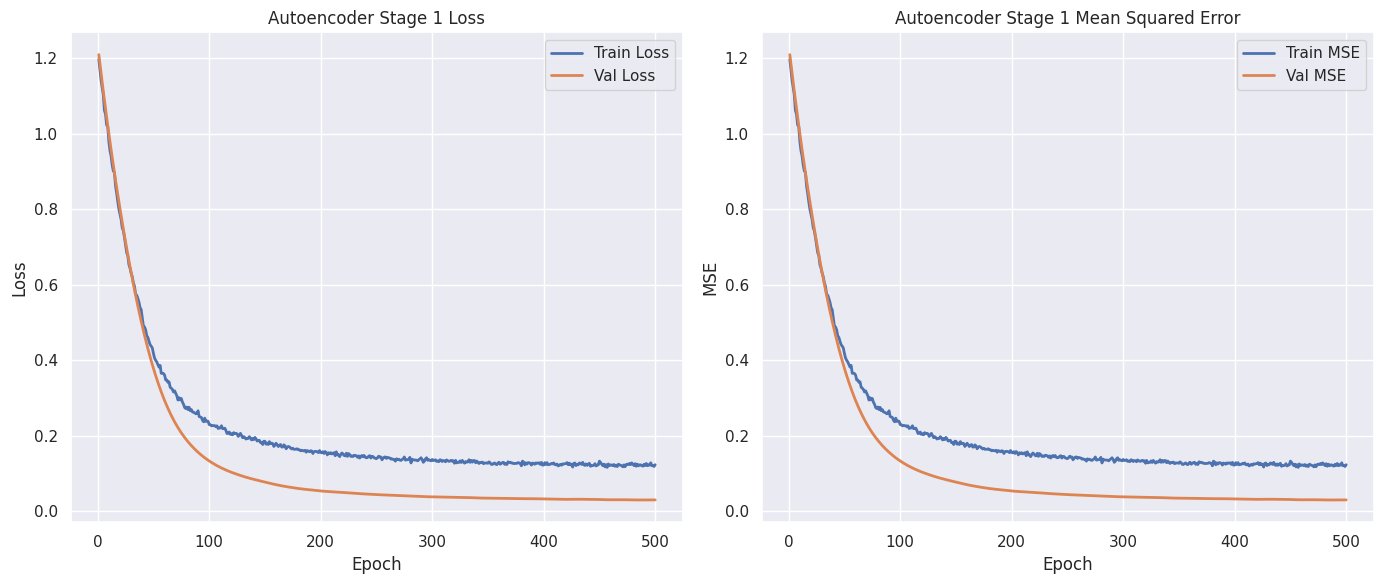

Autoencoder Stage 1 | Epoch 0500/500
train_loss=0.1238 | val_loss=0.0306 | train_mse=0.1238 | val_mse=0.0306


,train_loss,val_loss
495,0.128848,0.030762
496,0.121218,0.030730
497,0.121428,0.030724
498,0.119059,0.030688
499,0.123768,0.030622


In [6]:
stage1_history = train_autoencoder_stage(
    model=stage1_autoencoder,
    train_loader=ae_train_loader,
    val_loader=ae_val_loader,
    epochs=STAGE1_EPOCHS,
    stage_name="Autoencoder Stage 1",
)

torch.save(
    {"model_state_dict": stage1_autoencoder.state_dict()},
    UNSUP_ROOT / "stage1_autoencoder_final.pt",
)

stage1_history.tail()


In [7]:
stage2_autoencoder = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, X_train.shape[1]),
).to(device)

with torch.no_grad():
    stage2_autoencoder[0].weight.copy_(stage1_autoencoder[0].weight)
    stage2_autoencoder[0].bias.copy_(stage1_autoencoder[0].bias)

for parameter in stage2_autoencoder[0].parameters():
    parameter.requires_grad = False

print(stage2_autoencoder)
print(parameter_counts(stage2_autoencoder))


Sequential(
  (0): Linear(in_features=7, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Linear(in_features=32, out_features=7, bias=True)
)
{'total_params': 2823, 'trainable_params': 2311, 'non_trainable_params': 512}


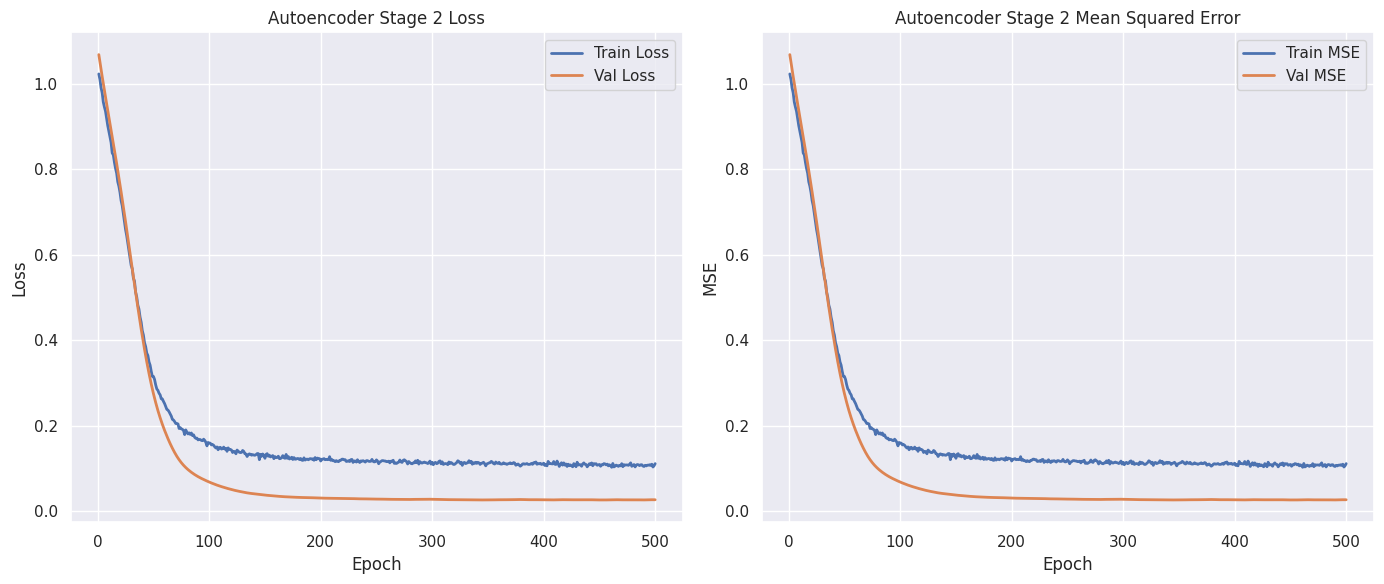

Autoencoder Stage 2 | Epoch 0500/500
train_loss=0.1108 | val_loss=0.0261 | train_mse=0.1108 | val_mse=0.0261


,train_loss,val_loss
495,0.106437,0.026194
496,0.109371,0.026180
497,0.102831,0.026148
498,0.105780,0.026133
499,0.110767,0.026127


In [8]:
stage2_history = train_autoencoder_stage(
    model=stage2_autoencoder,
    train_loader=ae_train_loader,
    val_loader=ae_val_loader,
    epochs=STAGE2_EPOCHS,
    stage_name="Autoencoder Stage 2",
)

torch.save(
    {"model_state_dict": stage2_autoencoder.state_dict()},
    UNSUP_ROOT / "stage2_autoencoder_final.pt",
)

stage2_history.tail()


In [9]:
classifier_model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid(),
).to(device)

with torch.no_grad():
    classifier_model[0].weight.copy_(stage2_autoencoder[0].weight)
    classifier_model[0].bias.copy_(stage2_autoencoder[0].bias)
    classifier_model[3].weight.copy_(stage2_autoencoder[3].weight)
    classifier_model[3].bias.copy_(stage2_autoencoder[3].bias)

for parameter in classifier_model[0].parameters():
    parameter.requires_grad = False
for parameter in classifier_model[3].parameters():
    parameter.requires_grad = False

print(classifier_model)
print(parameter_counts(classifier_model))


Sequential(
  (0): Linear(in_features=7, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Linear(in_features=32, out_features=1, bias=True)
  (6): Sigmoid()
)
{'total_params': 2625, 'trainable_params': 33, 'non_trainable_params': 2592}


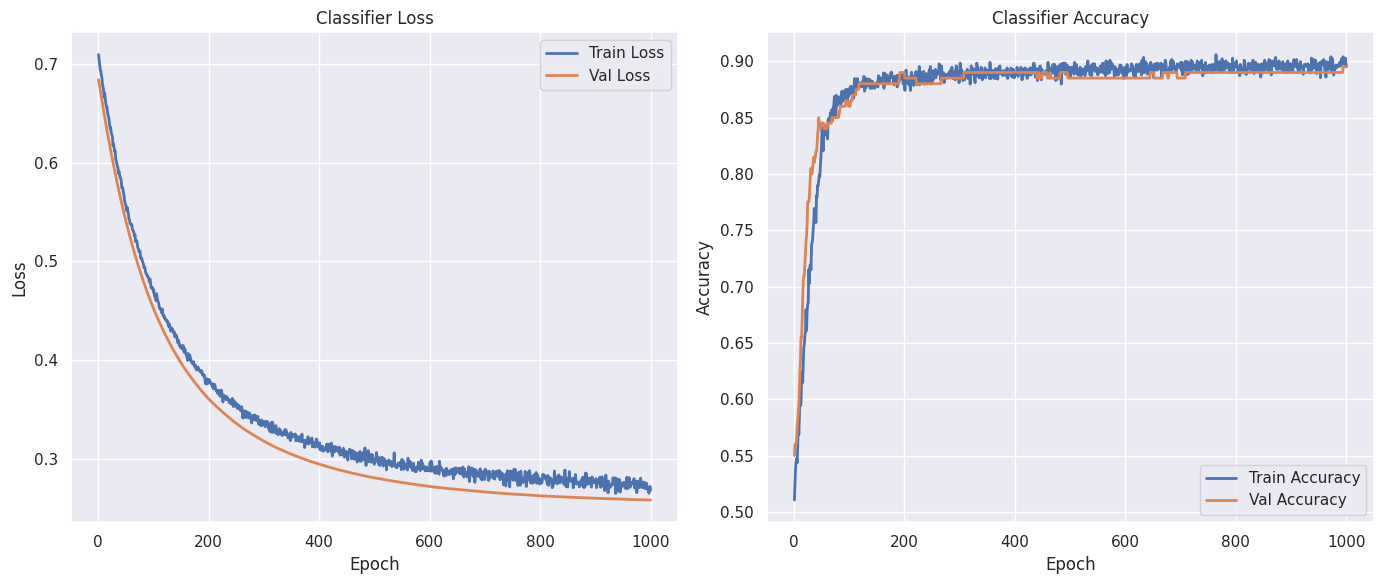

Classifier Stage | Epoch 1000/1000
train_loss=0.2680 | val_loss=0.2581 | train_acc=0.8959 | val_acc=0.8950


,train_loss,val_loss,train_accuracy,val_accuracy
995,0.270503,0.258140,0.897132,0.895
996,0.264857,0.258128,0.899626,0.895
997,0.269619,0.258115,0.902743,0.895
998,0.271829,0.258102,0.897756,0.895
999,0.268044,0.258089,0.895885,0.895


In [10]:
classifier_history = train_classifier_stage(
    model=classifier_model,
    train_loader=clf_train_loader,
    val_loader=clf_val_loader,
    epochs=FINAL_EPOCHS,
    checkpoint_dir=UNSUP_CKPT_DIR,
)

torch.save(
    {"model_state_dict": classifier_model.state_dict()},
    UNSUP_ROOT / "classifier_last.pt",
)

classifier_history.tail()


In [11]:
checkpoint_files = sorted(UNSUP_CKPT_DIR.glob("weights_epoch_*.pt"))
val_rows = []

for checkpoint_path in checkpoint_files:
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    val_model = nn.Sequential(
        nn.Linear(X_train.shape[1], 64),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1),
        nn.Sigmoid(),
    ).to(device)

    val_model.load_state_dict(checkpoint["model_state_dict"])
    val_model.eval()

    val_loss_sum = 0.0
    criterion = nn.BCELoss()

    with torch.no_grad():
        for features_batch, targets_batch in clf_val_loader:
            features_batch = features_batch.to(device)
            targets_batch = targets_batch.to(device)
            probabilities = val_model(features_batch)
            loss = criterion(probabilities, targets_batch)
            val_loss_sum += loss.item() * targets_batch.size(0)

    val_probabilities, val_targets = collect_classifier_outputs(val_model, clf_val_loader)
    val_metrics = compute_classifier_metrics(val_targets, val_probabilities)
    val_metrics["loss"] = val_loss_sum / len(clf_val_loader.dataset)
    val_metrics["epoch"] = int(checkpoint["epoch"])
    val_metrics["checkpoint_path"] = str(checkpoint_path)
    val_rows.append(val_metrics)

val_results_df = pd.DataFrame(val_rows).sort_values("epoch").reset_index(drop=True)

metrics_to_track = [
    "loss",
    "accuracy",
    "auc",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
    "precision_0",
    "precision_1",
    "recall_0",
    "recall_1",
    "f1_0",
    "f1_1",
]

best_rows = []
for metric_name in metrics_to_track:
    if metric_name == "loss":
        best_idx = val_results_df[metric_name].idxmin()
    else:
        best_idx = val_results_df[metric_name].idxmax()

    best_row = val_results_df.loc[best_idx]
    best_rows.append(
        {
            "metric": metric_name,
            "epoch": int(best_row["epoch"]),
            "score": float(best_row[metric_name]),
            "checkpoint_path": best_row["checkpoint_path"],
        }
    )

best_by_metric_df = pd.DataFrame(best_rows).set_index("metric")

print("Best validation epoch for each metric:")
best_by_metric_df


Best validation epoch for each metric:


,epoch,score,checkpoint_path
metric,,,
loss,1000,0.258089,greedy_unsupervised_ckpts/weights_epoch_1000.pt
accuracy,994,0.895000,greedy_unsupervised_ckpts/weights_epoch_0994.pt
auc,435,0.953095,greedy_unsupervised_ckpts/weights_epoch_0435.pt
precision_weighted,994,0.896872,greedy_unsupervised_ckpts/weights_epoch_0994.pt
recall_weighted,994,0.895000,greedy_unsupervised_ckpts/weights_epoch_0994.pt
f1_weighted,994,0.895712,greedy_unsupervised_ckpts/weights_epoch_0994.pt
precision_0,994,0.934307,greedy_unsupervised_ckpts/weights_epoch_0994.pt
precision_1,994,0.809524,greedy_unsupervised_ckpts/weights_epoch_0994.pt
recall_0,192,0.914286,greedy_unsupervised_ckpts/weights_epoch_0192.pt


Testing checkpoint from metric 'loss' at epoch 1000
accuracy              0.860697
auc                   0.951182
precision_weighted    0.873840
recall_weighted       0.860697
f1_weighted           0.864053
precision_0           0.938462
precision_1           0.718310
recall_0              0.859155
recall_1              0.864407
f1_0                  0.897059
f1_1                  0.784615
dtype: float64

              precision    recall  f1-score   support

         BLL      0.938     0.859     0.897       142
        FSRQ      0.718     0.864     0.785        59

    accuracy                          0.861       201
   macro avg      0.828     0.862     0.841       201
weighted avg      0.874     0.861     0.864       201



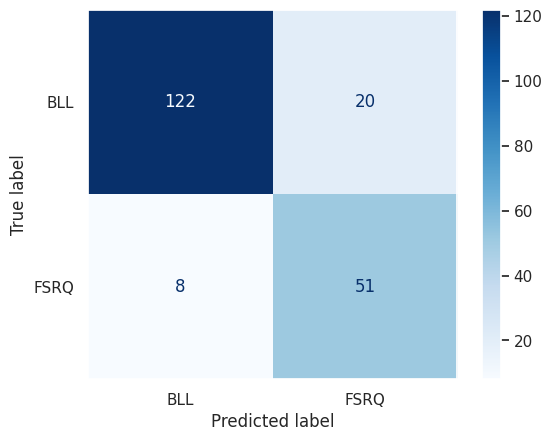

In [12]:
SELECTED_METRIC = "loss"
SELECTED_TEST_EPOCH = int(best_by_metric_df.loc[SELECTED_METRIC, "epoch"])
print(f"Testing checkpoint from metric '{SELECTED_METRIC}' at epoch {SELECTED_TEST_EPOCH}")

selected_checkpoint = UNSUP_CKPT_DIR / f"weights_epoch_{SELECTED_TEST_EPOCH:04d}.pt"
selected_state = torch.load(selected_checkpoint, map_location=device, weights_only=False)

test_model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
    nn.Sigmoid(),
).to(device)

test_model.load_state_dict(selected_state["model_state_dict"])
test_model.eval()

test_probabilities, test_targets = collect_classifier_outputs(test_model, clf_test_loader)
test_predictions = (test_probabilities >= 0.5).astype(int)
test_metrics = compute_classifier_metrics(test_targets, test_probabilities)

print(pd.Series(test_metrics))
print()
print(classification_report(test_targets, test_predictions, target_names=["BLL", "FSRQ"], digits=3))

sns.set(style="dark")
cm = confusion_matrix(test_targets, test_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["BLL", "FSRQ"])
disp.plot(cmap="Blues")
# plt.title(f"Test Confusion Matrix - Epoch {SELECTED_TEST_EPOCH}")
plt.savefig(UNSUP_ROOT / "Greedy_Unsupervised_Test_CM.png", dpi=300)
plt.show()


In [13]:
true_labels = np.asarray(test_targets).reshape(-1).astype(int)
pred_probs = np.asarray(test_probabilities).reshape(-1)

label_map = {0: "BLL", 1: "FSRQ"}

results_df = pd.DataFrame({
    "true_label": pd.Series(true_labels).map(label_map),
    "BLL": 1 - pred_probs,
    "FSRQ": pred_probs,
})

output_path = UNSUP_ROOT / "Greedy_Unsupervised_Test_Predictions.csv"
results_df.to_csv(output_path, index=False)

print("Saved to:", output_path.resolve())
results_df.head()


Saved to: /home/srinadb/BCU/BCUTorch/greedy_unsupervised_outputs/Greedy_Unsupervised_Test_Predictions.csv


,true_label,BLL,FSRQ
0,FSRQ,0.020391,0.979609
1,BLL,0.970348,0.029652
2,BLL,0.370082,0.629918
3,BLL,0.977478,0.022522
4,BLL,0.968823,0.031177


In [14]:
DATA_DIR = Path("./classification_data")

bcus = np.load(DATA_DIR / "bcu_samples.npy").astype(np.float32)

bcus_dataset = TensorDataset(
    torch.tensor(bcus, dtype=torch.float32)
)

bcus_loader = DataLoader(bcus_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("bcus:", bcus.shape)

test_model.load_state_dict(selected_state["model_state_dict"])
test_model.eval()

bcus_probabilities = collect_outputs_unlabeled(test_model, bcus_loader)
bcus_predictions = (bcus_probabilities >= 0.5).astype(int)


bcus: (1115, 7)


In [15]:
bcus_results_df = pd.DataFrame({
    "BLL": 1 - np.asarray(bcus_probabilities).reshape(-1),
    "FSRQ": np.asarray(bcus_probabilities).reshape(-1),
})

bcus_output_path = UNSUP_ROOT / "Greedy_Unsupervised_BCU_Predictions.csv"
bcus_results_df.to_csv(bcus_output_path, index=False)

print("Saved to:", bcus_output_path.resolve())
bcus_results_df.head()


Saved to: /home/srinadb/BCU/BCUTorch/greedy_unsupervised_outputs/Greedy_Unsupervised_BCU_Predictions.csv


,BLL,FSRQ
0,0.649513,0.350487
1,0.965570,0.034430
2,0.967743,0.032257
3,0.965554,0.034446
4,0.972267,0.027733


### Testing

In [16]:
from utils import analyze_prediction_sets, create_and_plot_histograms_test_csv

BLL count : 130
FSRQ count: 71


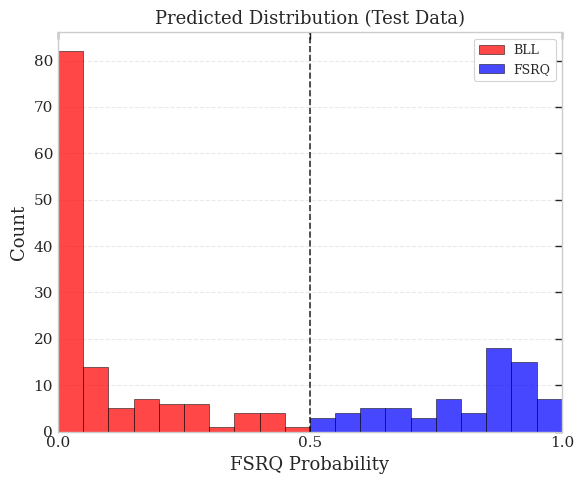

In [17]:
create_and_plot_histograms_test_csv(
    test_csv_path='./greedy_unsupervised_outputs/Greedy_Unsupervised_Test_Predictions.csv',
    title='Predicted Distribution (Test Data)',
    save_path='./greedy_unsupervised_outputs/Greedy_Unsupervised_Test_histogram.png',
)


BLL count : 712
FSRQ count: 403


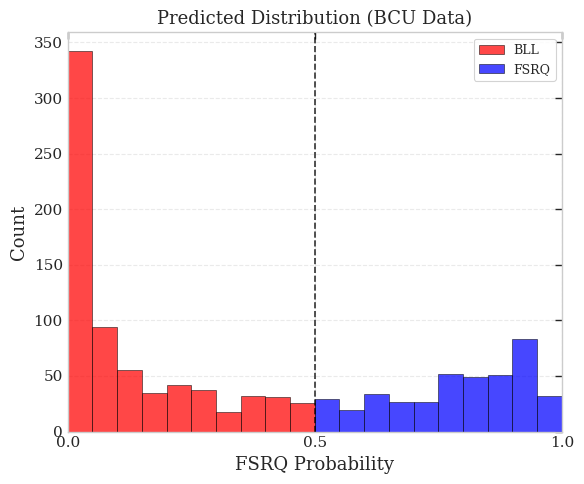

In [18]:
create_and_plot_histograms_test_csv(
    test_csv_path='./greedy_unsupervised_outputs/Greedy_Unsupervised_BCU_Predictions.csv',
    title='Predicted Distribution (BCU Data)',
    save_path='./greedy_unsupervised_outputs/Greedy_Unsupervised_BCU_histogram.png',
)

Requested alpha : 0.1
Using alpha     : 0.1
qhat_BLL        : 0.4838773906230926
qhat_FSRQ       : 0.5424582958221436

Prediction-set counts at fixed alpha
BLL only : 129
FSRQ only: 72
Both set : 0
Empty set: 0
Total    : 201


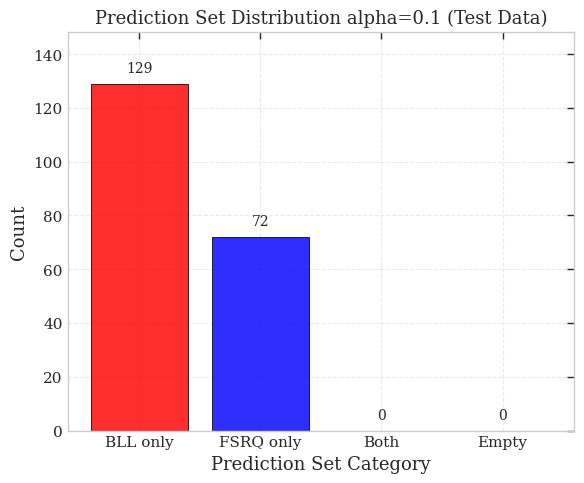

In [19]:
results = analyze_prediction_sets(
    qhat_csv='./greedy_unsupervised_outputs/greedy_unsupervised_qhat_mccp.csv',
    test_csv='./greedy_unsupervised_outputs/Greedy_Unsupervised_Test_Predictions.csv',
    alpha_target=0.1,
    save_path='./greedy_unsupervised_outputs/Greedy_Unsupervised_Test_prediction_set_distribution_alpha.png',
    title="Prediction Set Distribution alpha=0.1 (Test Data)",
)


Requested alpha : 0.1
Using alpha     : 0.1
qhat_BLL        : 0.4838773906230926
qhat_FSRQ       : 0.5424582958221436

Prediction-set counts at fixed alpha
BLL only : 688
FSRQ only: 415
Both set : 12
Empty set: 0
Total    : 1115


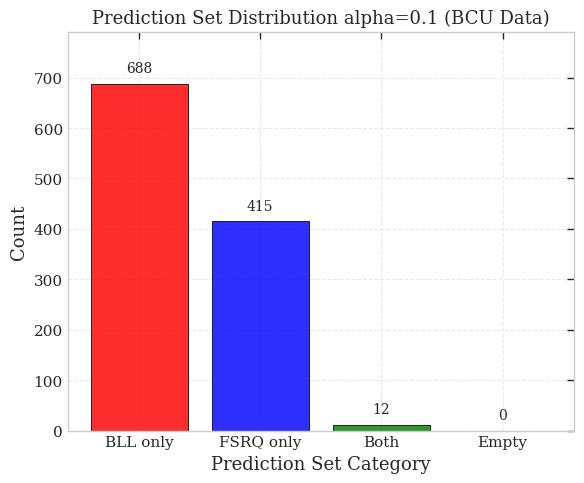

In [20]:
results_bcu = analyze_prediction_sets(
    qhat_csv='./greedy_unsupervised_outputs/greedy_unsupervised_qhat_mccp.csv',
    test_csv='./greedy_unsupervised_outputs/Greedy_Unsupervised_BCU_Predictions.csv',
    alpha_target=0.1,
    save_path='./greedy_unsupervised_outputs/Greedy_Unsupervised_BCU_prediction_set_distribution_alpha.png',
    title="Prediction Set Distribution alpha=0.1 (BCU Data)",
)

In [21]:
prefix = "Greedy_Unsupervised"
alpha = 0.1
random_state = 0

def save_plot_bundle(mcp, output_dir, prefix=prefix, include_fig2_scatter=True):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    mcp.plot_all(
        output_dir=str(output_dir),
        prefix=prefix,
        show=False,
        include_fig2_scatter=include_fig2_scatter,
    )

    png_plotters = [
        ("coverage", mcp.plot_coverage),
        ("setsize", mcp.plot_set_size),
        ("roc", mcp.plot_roc),
        ("alpha_metrics", mcp.plot_alpha_metrics),
    ]
    if include_fig2_scatter:
        png_plotters.append(("scatter", mcp.plot_prediction_set_scatter))

    for name, plotter in png_plotters:
        plotter(save_path=output_dir / f"{prefix}_{name}.png", show=False)
        

['FSRQ' 'BLL']
['true_label', 'BLL', 'FSRQ']
Qhat rows   : 52 alpha values
Test        : 201 samples
Classes     : ['BLL', 'FSRQ']

Running unified alpha sweep …
Computing macro ROC …

Macro AUC = 0.9512 | MCP AUC ≈ 0.9470

-----------------------------------------------
  MCP Metrics Summary   alpha = 0.1000
-----------------------------------------------
  Calibration samples : 1604
  Test samples        : 201
  Classes             : 2
-----------------------------------------------
  Coverage            : 0.8557   (target >= 0.9000)
  Macro F1-score      : 0.8358
  Average set size    : 1.0000
  Singleton rate      : 0.8557
  True positive rate  : 0.8557
  False positive rate : 0.1443
-----------------------------------------------
  Per-class F1:
    BLL                          0.8930
    FSRQ                         0.7786
-----------------------------------------------
  Saved: greedy_unsupervised_outputs/Greedy_Unsupervised_coverage.pdf
  Saved: greedy_unsupervised_outputs/Gree

alpha                0.100000
n_cal             1604.000000
n_test             201.000000
n_classes            2.000000
coverage             0.855721
macro_f1             0.835807
avg_set_size         1.000000
singleton_rate       0.855721
fpr                  0.144279
tpr                  0.855721
dtype: float64

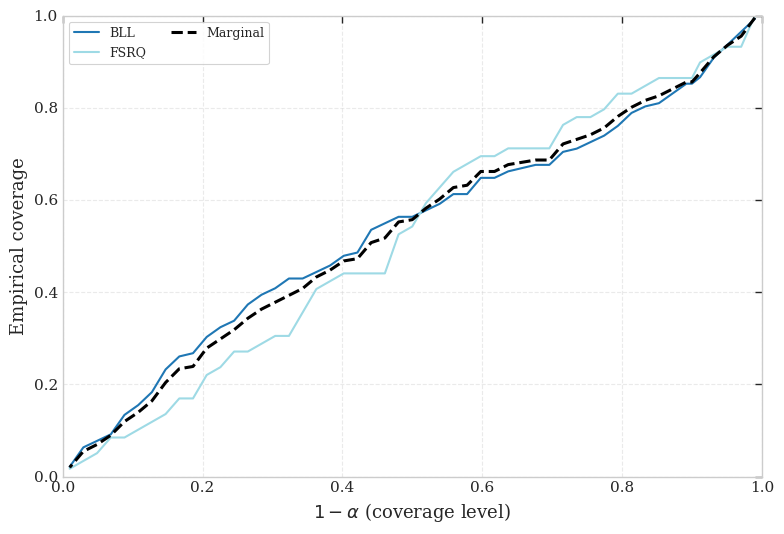

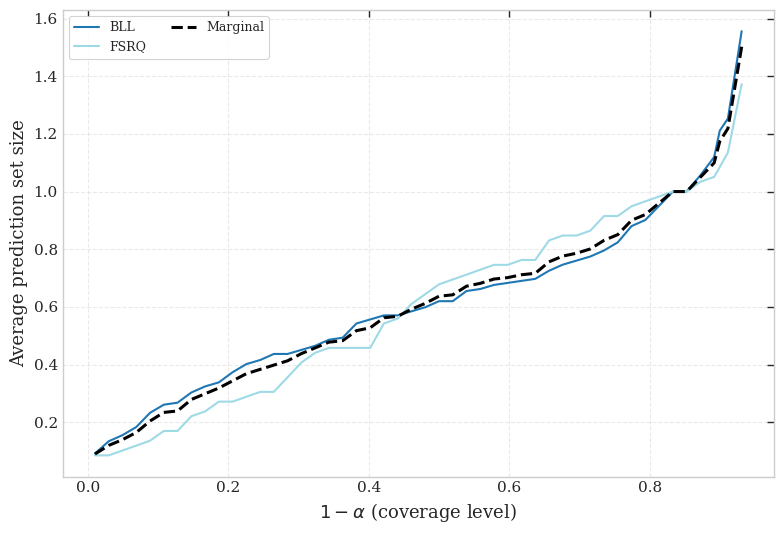

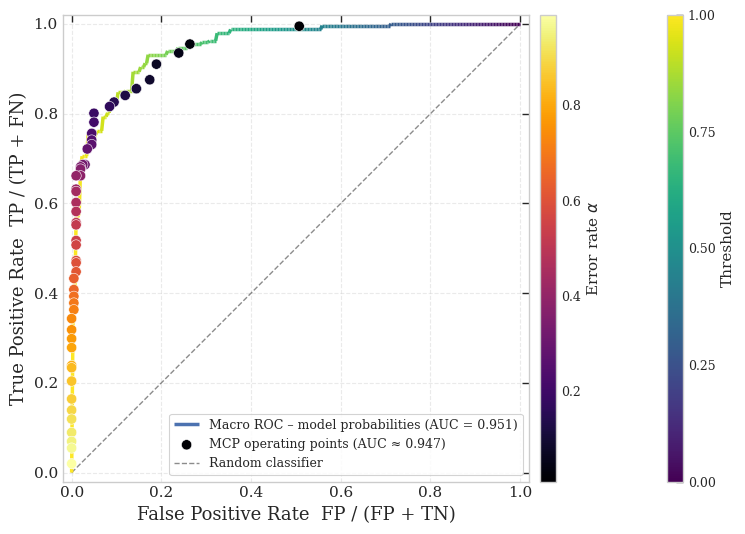

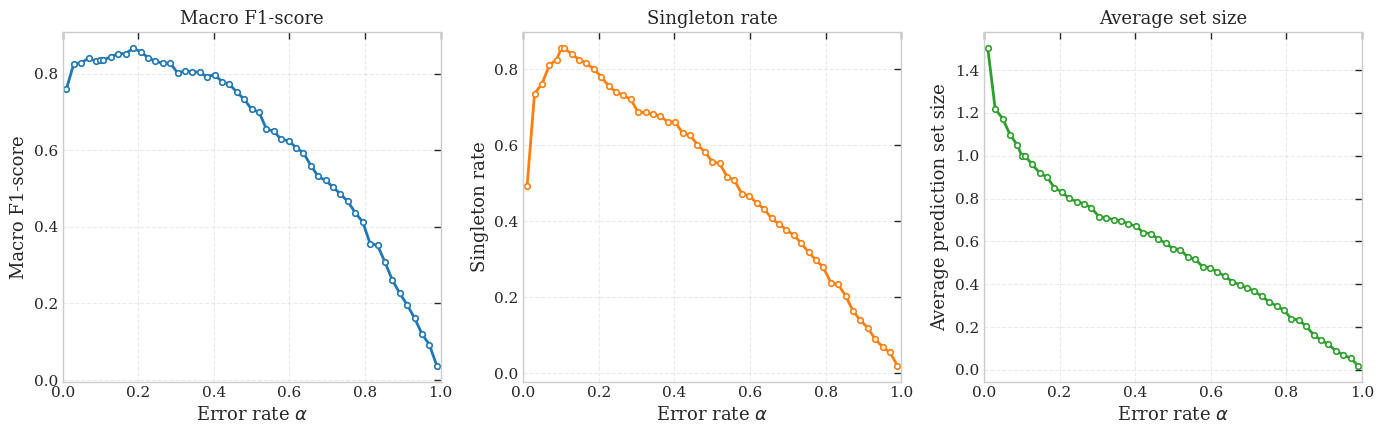

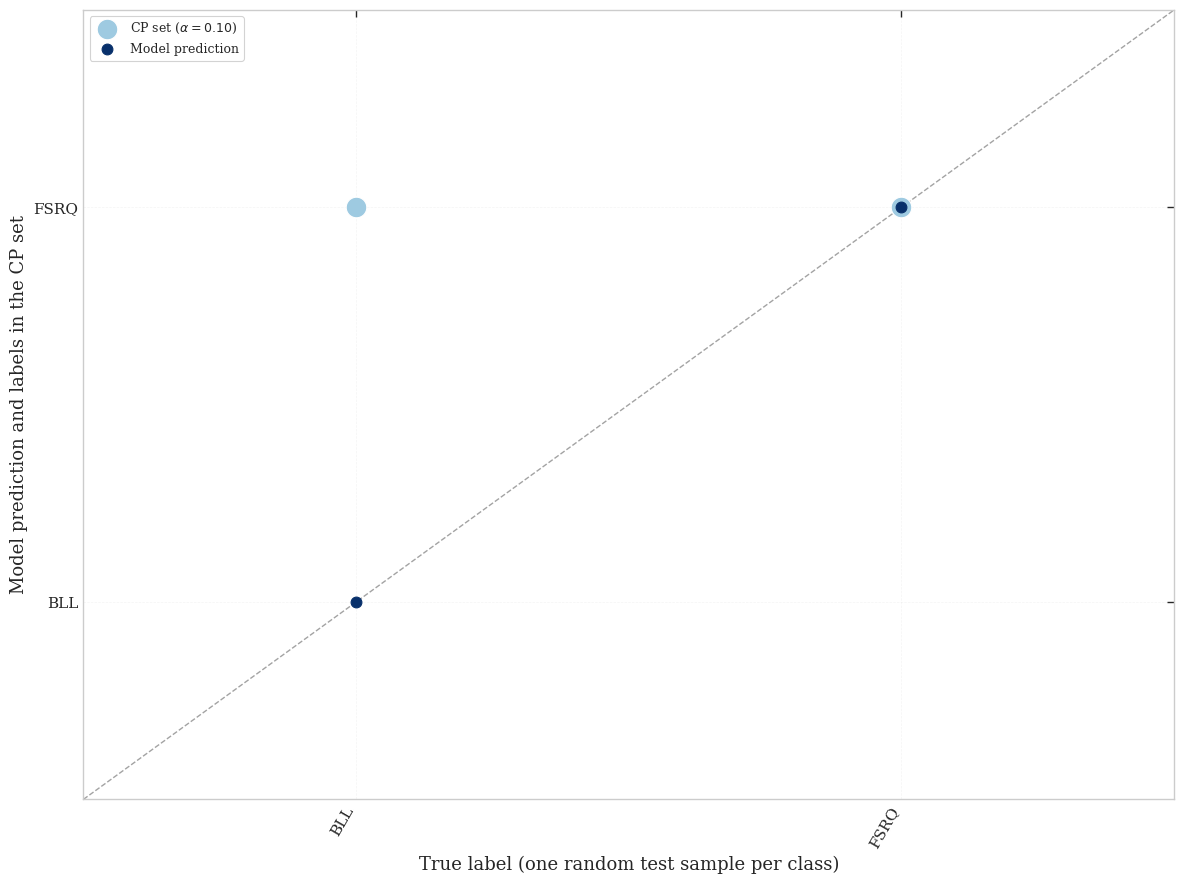

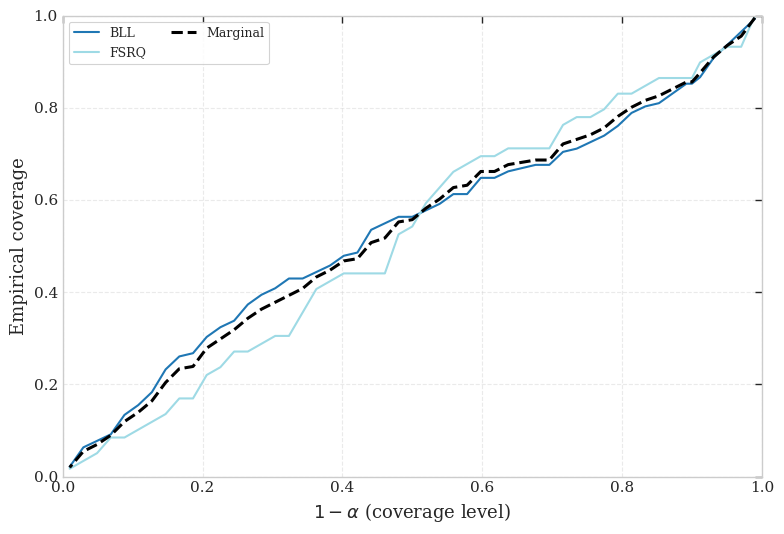

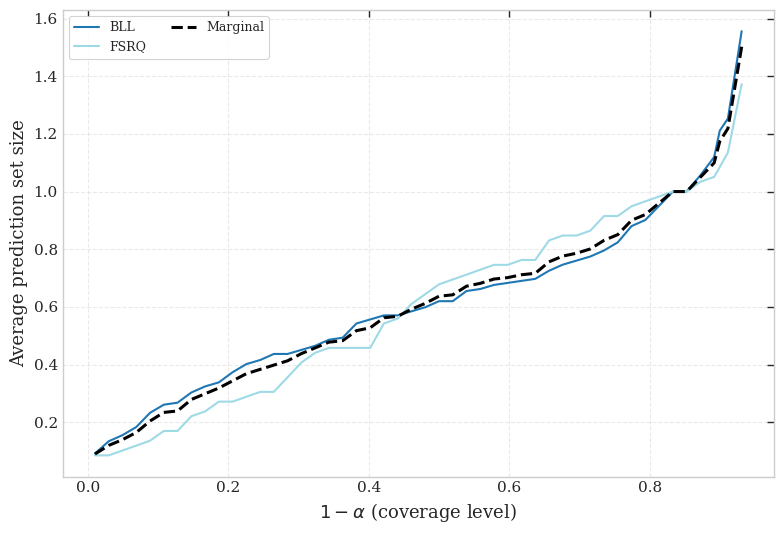

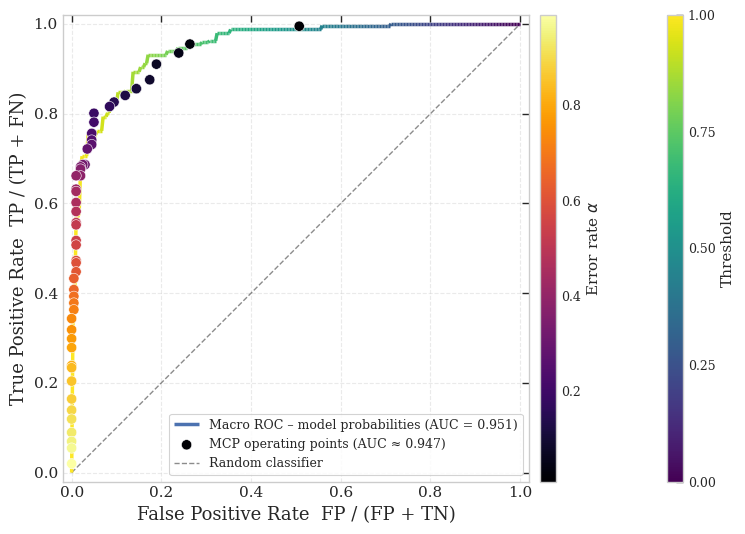

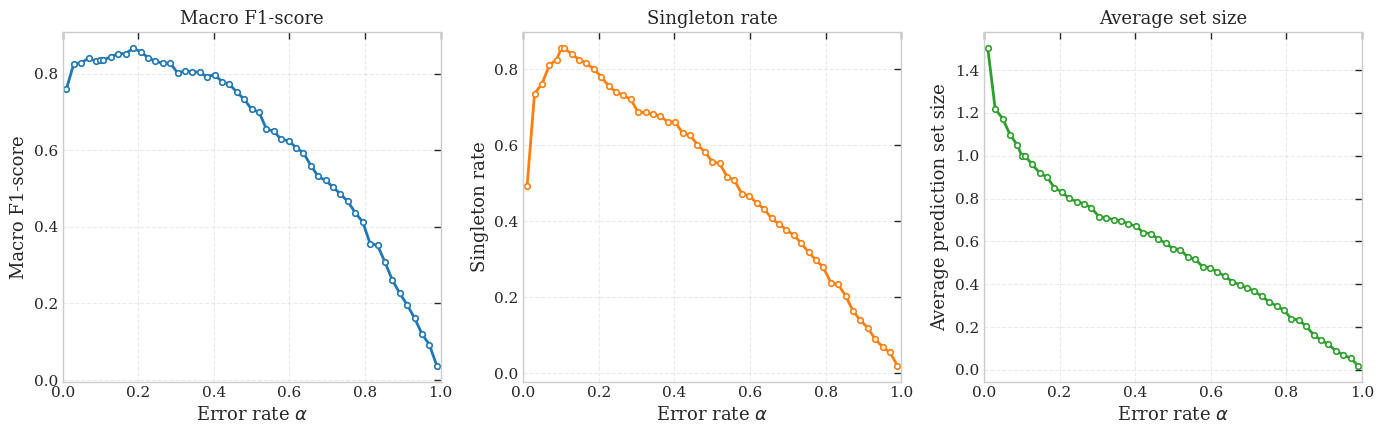

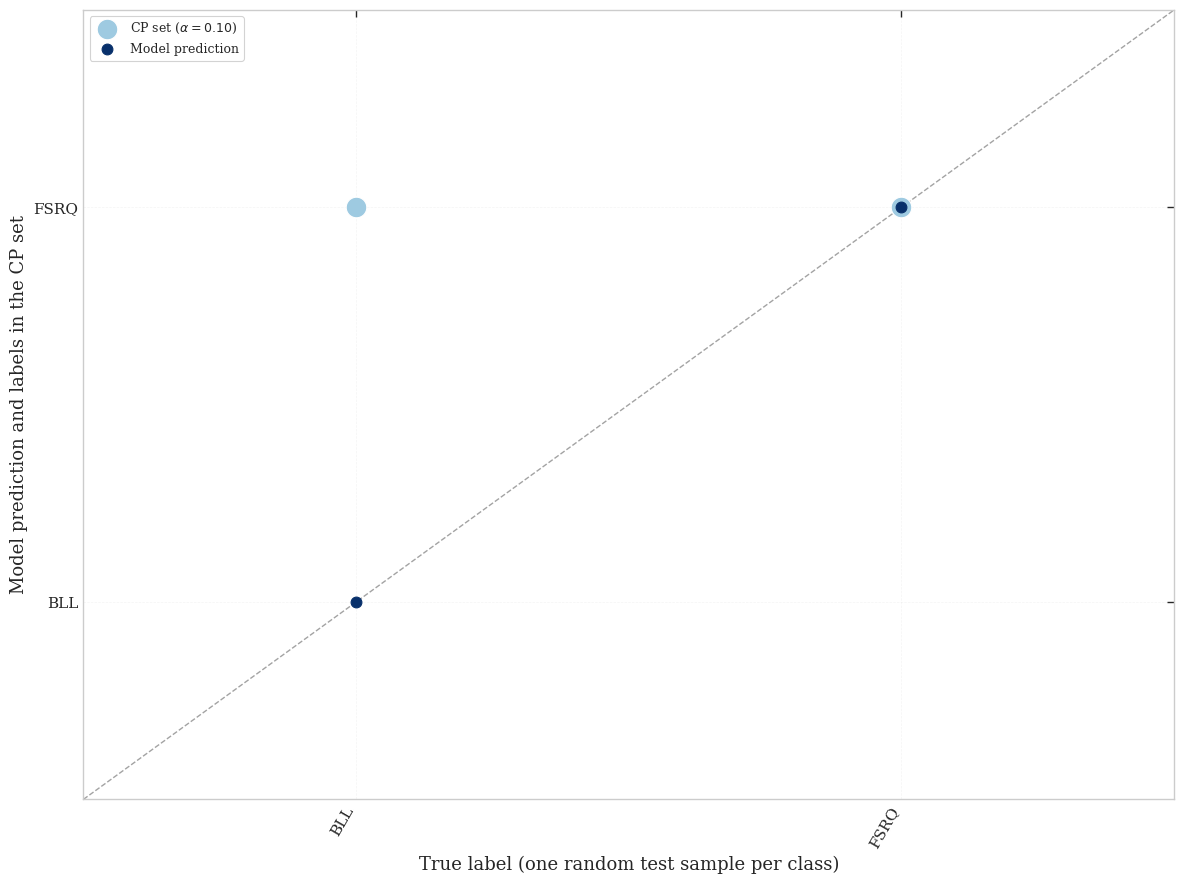

In [22]:
qhat_csv = './greedy_unsupervised_outputs/greedy_unsupervised_qhat_mccp.csv'
test_csv = './greedy_unsupervised_outputs/Greedy_Unsupervised_Test_Predictions.csv'

test_df = pd.read_csv(test_csv)

print(test_df["true_label"].unique())   # should already show ['BLL', 'FSRQ'] or ['FSRQ', 'BLL']
print(test_df.columns.tolist())         # should show ['true_label', 'BLL', 'FSRQ']

mcp_qhat = MCPTool.from_qhat_csv(
    qhat_csv,
    test_csv,
    alpha=alpha,
    random_state=random_state,
).run()

save_plot_bundle(mcp_qhat, UNSUP_ROOT)

summary = mcp_qhat.print_metrics()
pd.Series({k: v for k, v in summary.items() if k != "per_label_f1"})